In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv("insurance.csv") # df = dataframe
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()
df.describe()

df = pd.get_dummies(df, drop_first=True)
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [13]:
from sklearn.model_selection import train_test_split

X = df.drop("charges", axis=1)
y = df["charges"]

bool_columns = X.select_dtypes(include="bool").columns
X[bool_columns] = X[bool_columns].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)



from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

X_train shape: (1070, 8)
X_test shape: (268, 8)
Model trained successfully


Mean Absolute Error: 4181.194473753649
Mean Squared Error: 33596915.85136145
R-squared: 0.7835929767120724


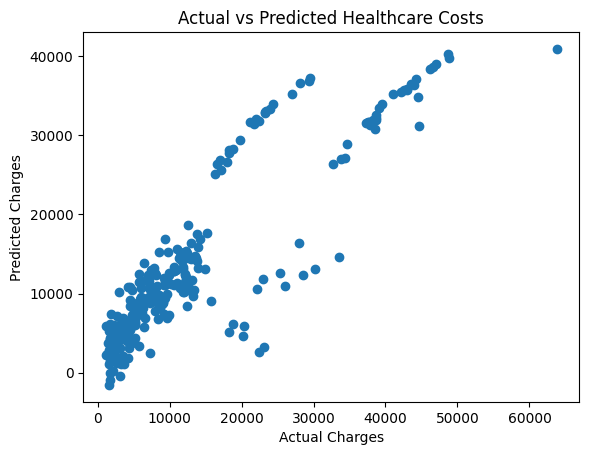

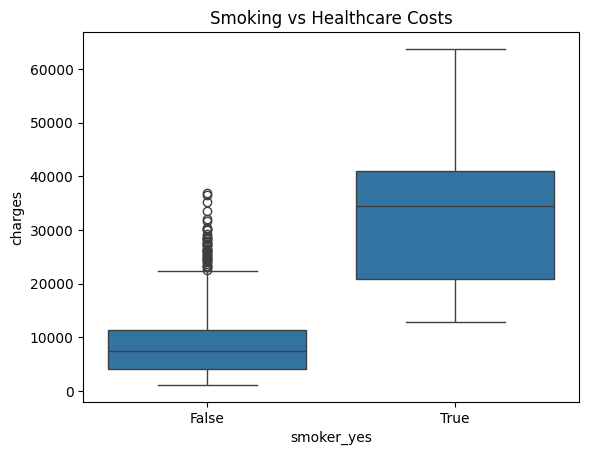

In [23]:
predictions = model.predict(X_test)
predictions[:5]

df = pd.read_csv("insurance.csv")
df = pd.get_dummies(df, drop_first=True)

X = df.drop("charges", axis=1)
y = df["charges"]

bool_columns = X.select_dtypes(include="bool").columns
X[bool_columns] = X[bool_columns].astype(int)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Mean Absolute Error:", mean_absolute_error(y_test, predictions))
print("Mean Squared Error:", mean_squared_error(y_test, predictions))
print("R-squared:", r2_score(y_test, predictions))


import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Healthcare Costs")
plt.savefig("prediction_plot1.png")
plt.show()


coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)


sns.boxplot(x="smoker_yes", y="charges", data=df)
plt.title("Smoking vs Healthcare Costs")

plt.savefig("prediction_plot2.png")
plt.show()


